In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_sp_raw = pd.read_csv('/content/sample_data/Ship_Engine.csv')
df_sp_raw
df_sp_raw.head(10)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
0,682,2.391656,4.617196,2.848982,76.272417,69.884609
1,605,5.466877,6.424361,5.727520,73.222679,74.907314
2,658,3.434232,3.680896,1.678708,88.089916,78.704806
3,749,2.094656,7.120927,1.639670,77.661625,82.386700
4,676,3.538228,5.956472,3.225336,75.226352,67.153220
5,589,2.933888,6.358464,2.461478,77.534616,75.403745
6,885,2.034509,15.499680,1.522790,78.959645,80.817985
7,576,5.495972,13.114658,1.251058,78.091390,71.934674
8,535,3.159440,8.676361,1.265139,82.408722,80.752747
9,806,3.946885,21.138326,1.572569,74.923316,72.112692


Find the Null or NA data in the dataset

In [2]:
df_sp_raw.isna().sum()

,0
Engine rpm,0
Lub oil pressure,0
Fuel pressure,0
Coolant pressure,0
lub oil temp,0
Coolant temp,0


In [7]:
print(df_sp_raw.duplicated().sum())

0


Check the distribution of the data for the features

In [3]:
df_sp_raw.describe()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
count,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000,19535.000000
mean,791.239263,3.303775,6.655615,2.335369,77.643420,78.427433
std,267.611193,1.021643,2.761021,1.036382,3.110984,6.206749
min,61.000000,0.003384,0.003187,0.002483,71.321974,61.673325
25%,593.000000,2.518815,4.916886,1.600466,75.725990,73.895421
50%,746.000000,3.162035,6.201720,2.166883,76.817350,78.346662
75%,934.000000,4.055272,7.744973,2.848840,78.071691,82.915411
max,2239.000000,7.265566,21.138326,7.478505,89.580796,195.527912


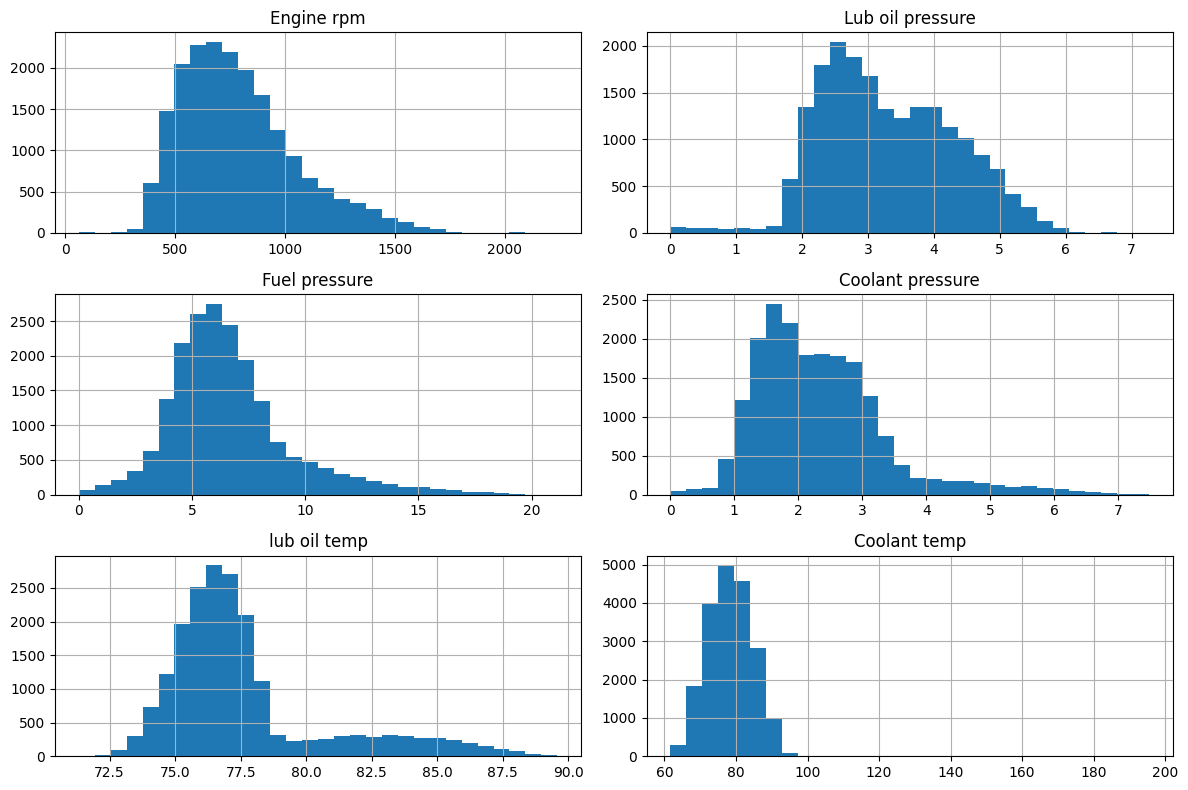

In [4]:
df_sp_raw.hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()


It seems that the distribution of the data related to the features are not normally distributed, they skewed.

In [5]:
df_sp_raw.skew()
df_sp_raw.kurt()

,0
Engine rpm,0.936921
Lub oil pressure,-0.260152
Fuel pressure,2.452666
Coolant pressure,2.556044
lub oil temp,1.749363
Coolant temp,5.880549


Box plot to identfy the outliers

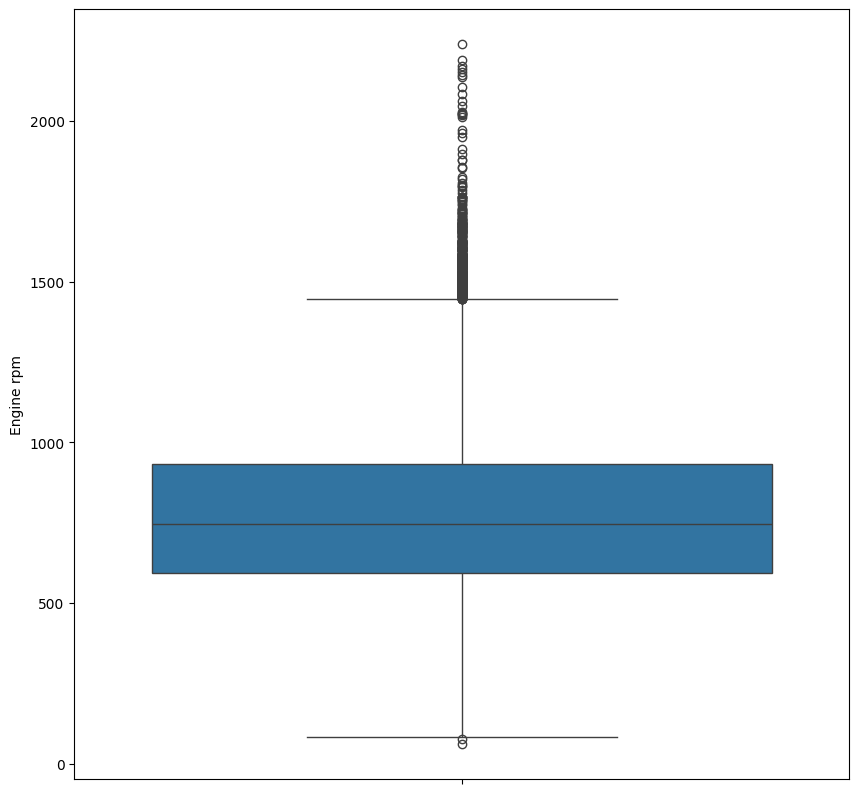

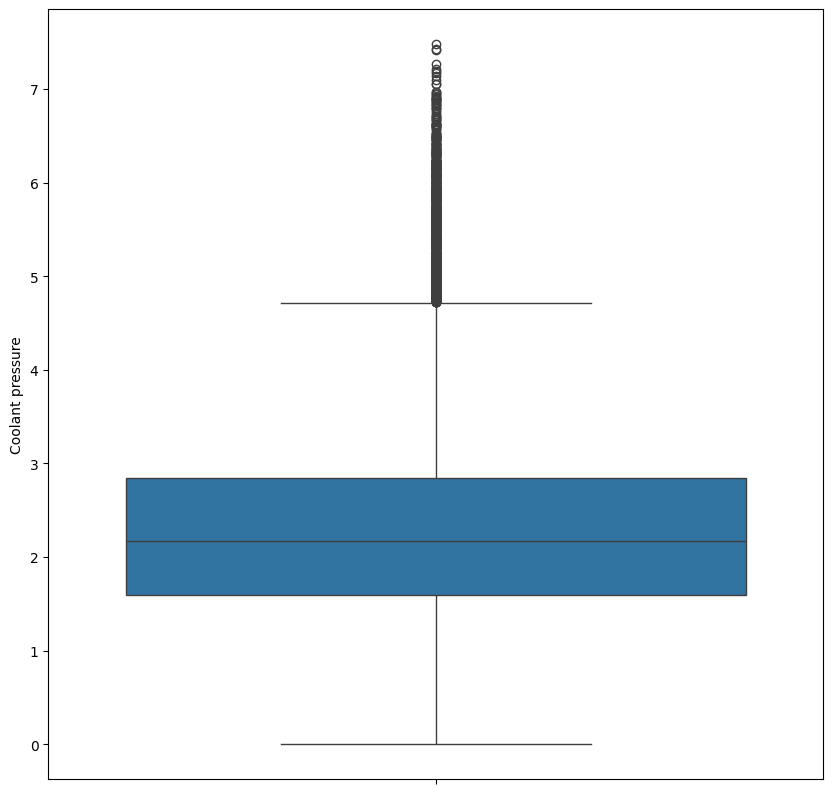

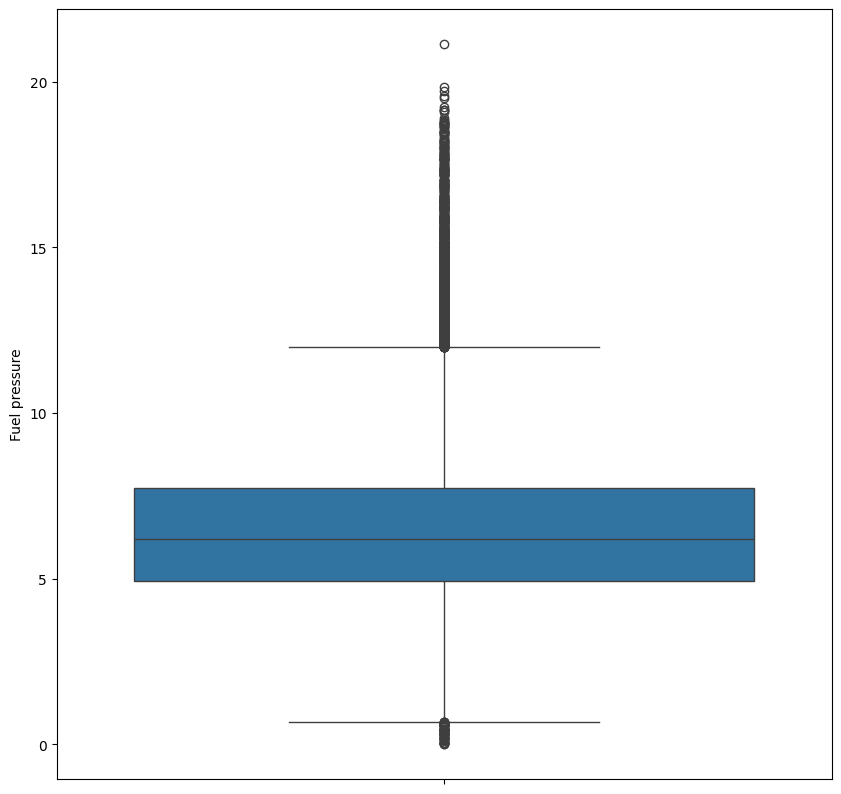

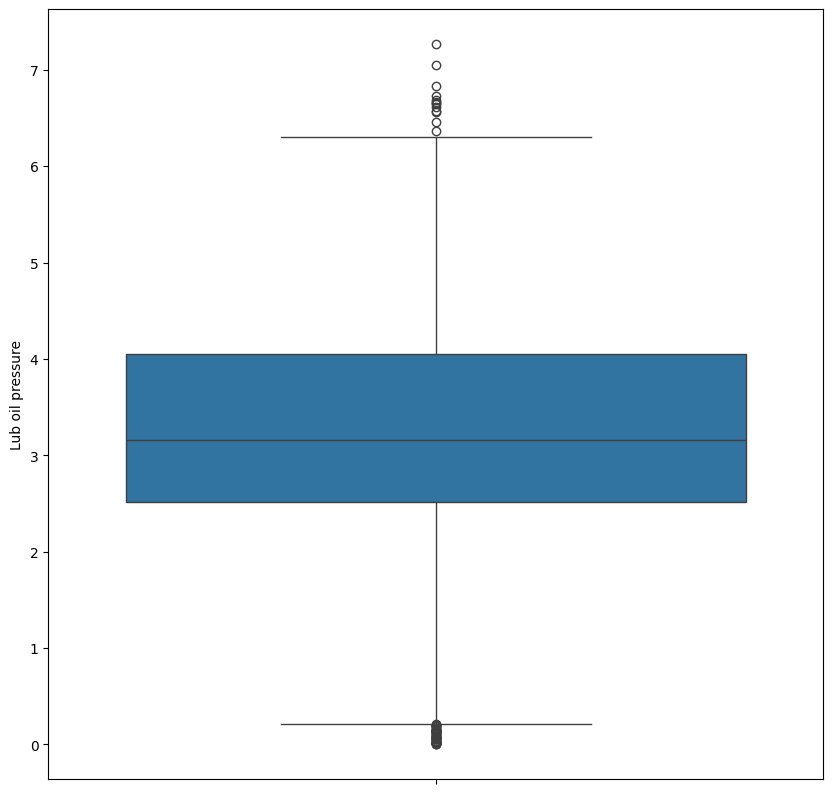

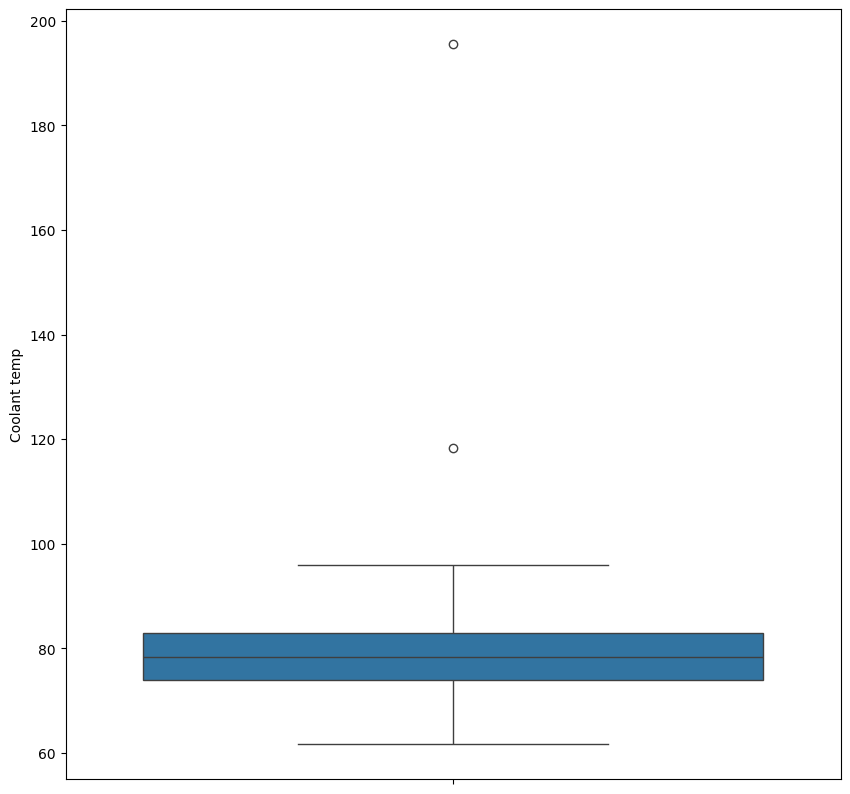

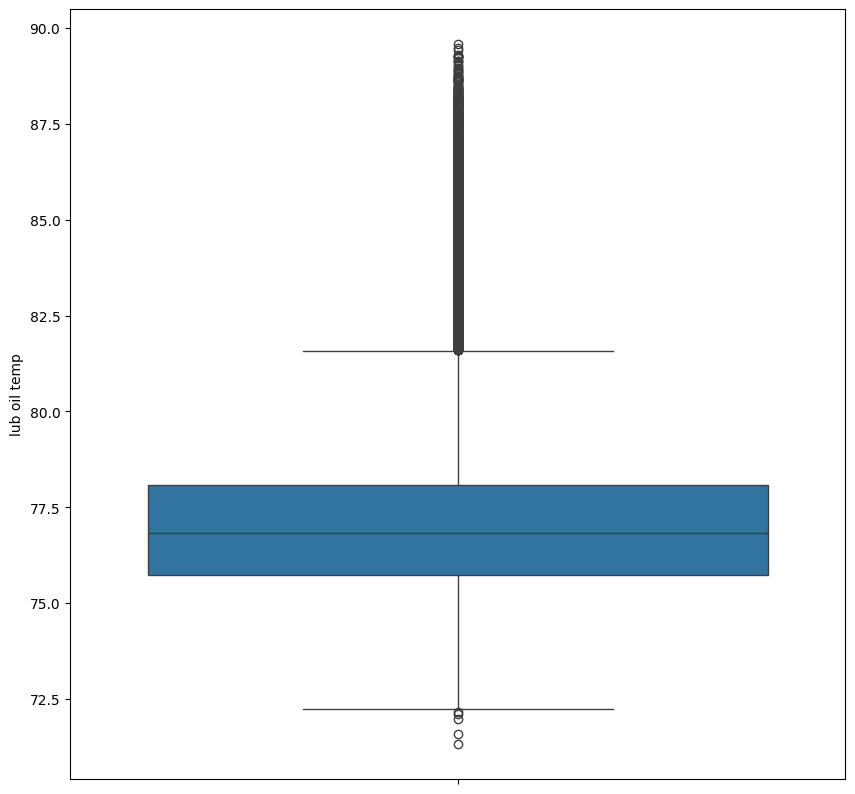

In [6]:
plt.figure(figsize=(10,10))
sns.boxplot(data=df_sp_raw['Engine rpm'])
plt.xticks(rotation=45)
plt.show()
plt.figure(figsize=(10,10))
sns.boxplot(data=df_sp_raw['Coolant pressure'])
plt.xticks(rotation=45)
plt.show()
plt.figure(figsize=(10,10))
sns.boxplot(data=df_sp_raw['Fuel pressure'])
plt.xticks(rotation=45)
plt.show()
plt.figure(figsize=(10,10))
sns.boxplot(data=df_sp_raw['Lub oil pressure'])
plt.xticks(rotation=45)
plt.show()
plt.figure(figsize=(10,10))
sns.boxplot(data=df_sp_raw['Coolant temp'])
plt.xticks(rotation=45)
plt.show()
plt.figure(figsize=(10,10))
sns.boxplot(data=df_sp_raw['lub oil temp'])
plt.xticks(rotation=45)
plt.show()


Pair plot

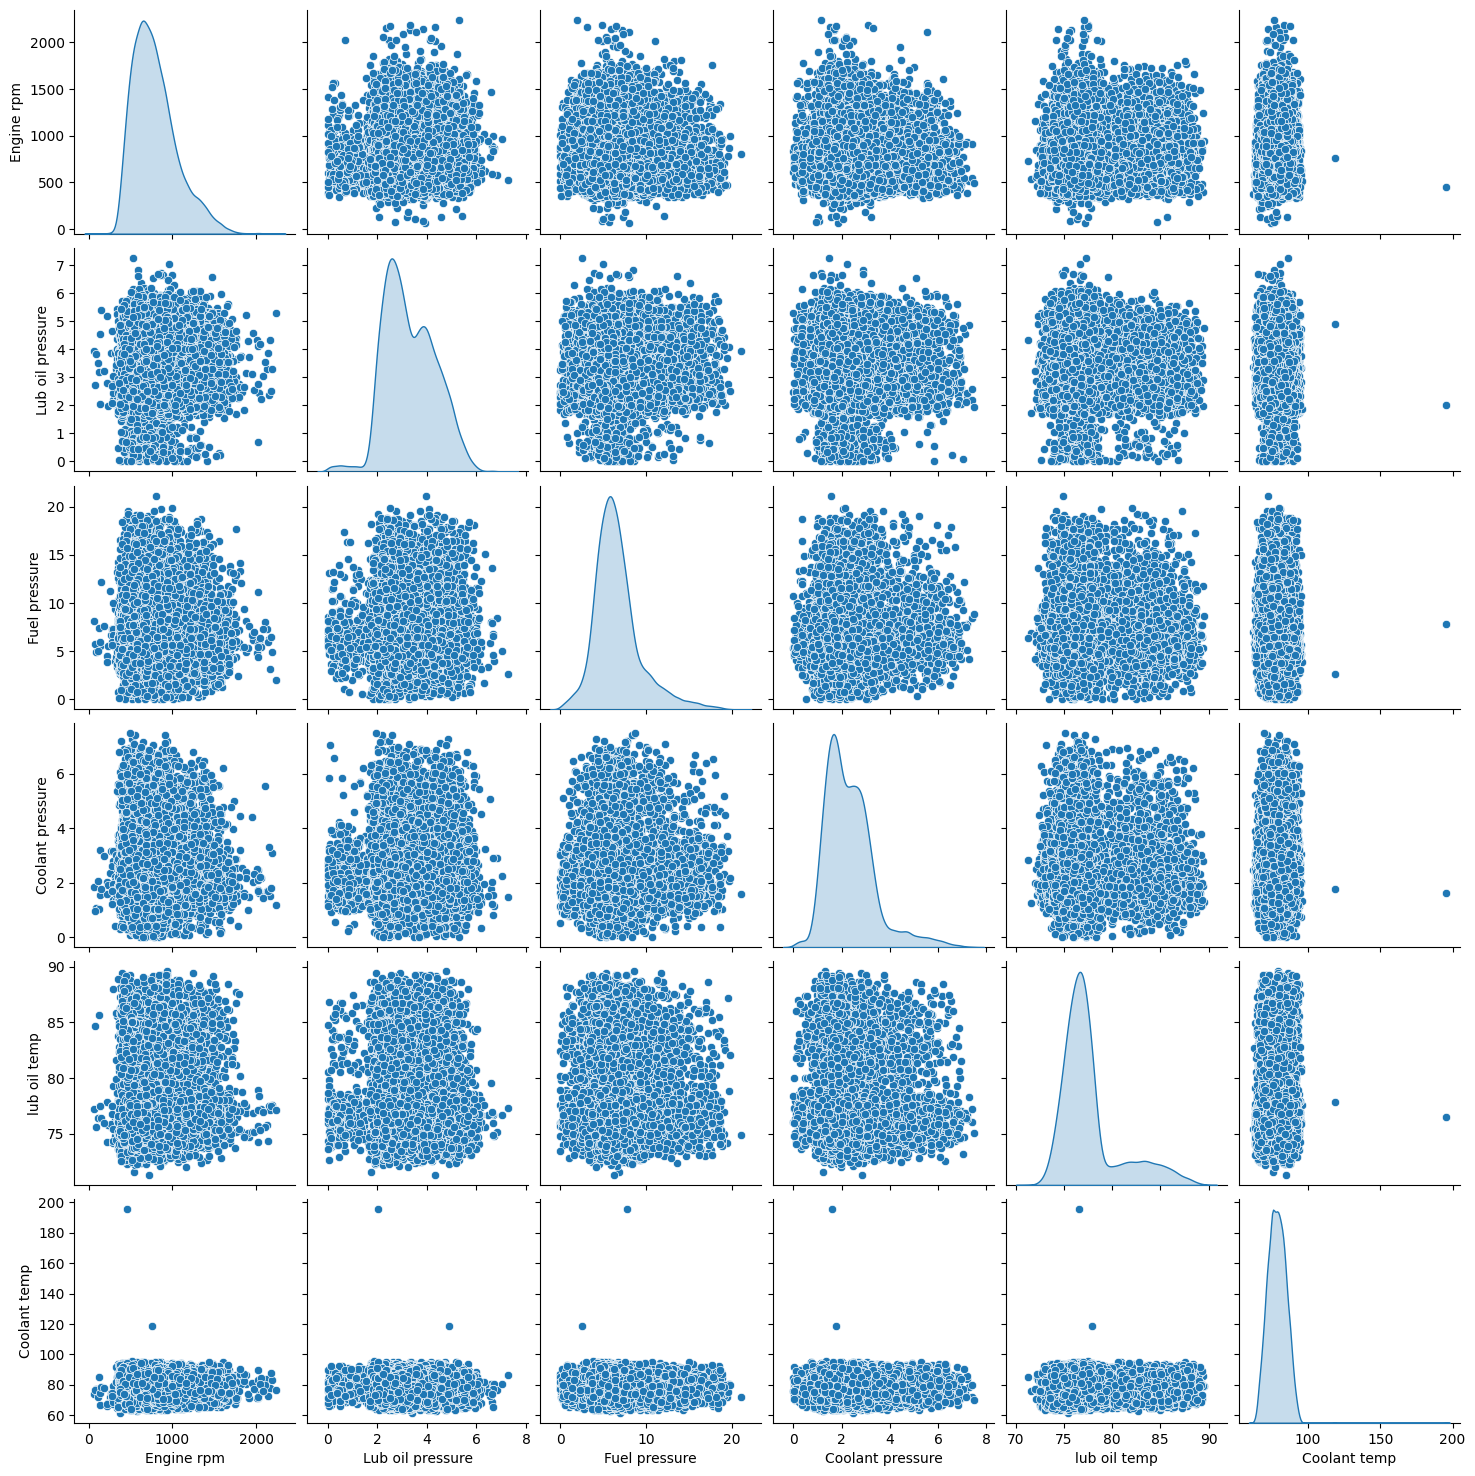

In [7]:
sns.pairplot(df_sp_raw, diag_kind="kde")   # kde gives smooth curves on the diagonal
plt.show()


Pair plot shows that the attributes/features are uncorrelated. Check the correlation coeff across different features

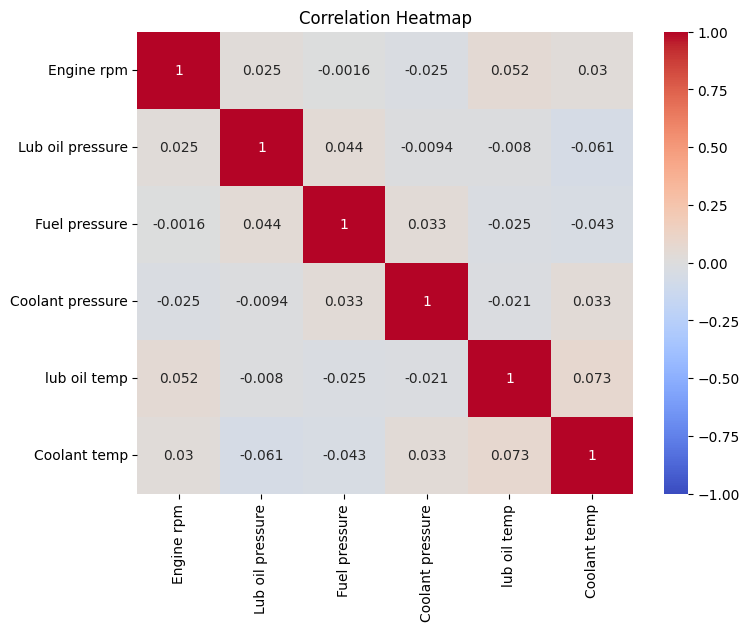

In [8]:
corr_matrix = df_sp_raw.corr()
corr_matrix

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()



- Deep red indicates strong positive correlation.
- Deep blue indicates strong negative correlation.
- White or pale colours indicate little or no correlation.


Detecting Outliers with IQR

IQR is suitable for univariate statistical analysis, when it is univariate or working with single feature, as IQR is applied on a series at a time, and it provides output for every individual feature.

Trying to perform a IQR to detect the anamoly for multivariate model.

In [9]:
df_iqr = df_sp_raw.copy()
df_iqr.head()

#iqr_outlier = {}

for col in df_iqr.columns:
    Q1 = df_iqr[col].quantile(0.25)
    Q3 = df_iqr[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = df_iqr[(df_iqr[col] < lower) | (df_iqr[col] > upper)]

mask

#iqr_outliers[col] = df_iqr[mask].index.tolist()

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp
3242,760,4.908028,2.594570,1.747730,77.873482,118.371957
10663,455,2.010802,7.806127,1.619575,76.519385,195.527912


For uncorrelated and multivariate feature data set the relevant method to find the anomaly is to use Isolation Forest algorithm. Isolation Forest applied on the Ship Engine data set.

In [10]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

df_iso = df_sp_raw.copy()

X = df_iso.iloc[:, :6]   # adjust if your feature columns differ

# Scaling helps Isolation Forest treat all features equally, especially when they have different ranges
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,   # adjust between 1% and 5%, I have used 5%
    random_state=42
)

iso.fit(X_scaled)

df_iso["anomaly_flag"] = iso.predict(X_scaled)
df_iso["anomaly_score"] = iso.decision_function(X_scaled)

df_iso.head(10)


,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,anomaly_flag,anomaly_score
0,682,2.391656,4.617196,2.848982,76.272417,69.884609,1,0.116000
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,-1,-0.024061
2,658,3.434232,3.680896,1.678708,88.089916,78.704806,1,0.022535
3,749,2.094656,7.120927,1.639670,77.661625,82.386700,1,0.134200
4,676,3.538228,5.956472,3.225336,75.226352,67.153220,1,0.091356
5,589,2.933888,6.358464,2.461478,77.534616,75.403745,1,0.153663
6,885,2.034509,15.499680,1.522790,78.959645,80.817985,1,0.025723
7,576,5.495972,13.114658,1.251058,78.091390,71.934674,1,0.017270
8,535,3.159440,8.676361,1.265139,82.408722,80.752747,1,0.082475
9,806,3.946885,21.138326,1.572569,74.923316,72.112692,1,0.011138


Find the anomalies

In [11]:
anomalies = df_iso[df_iso["anomaly_flag"] == -1]
anomalies.count()
anomalies.head(10)

,Engine rpm,Lub oil pressure,Fuel pressure,Coolant pressure,lub oil temp,Coolant temp,anomaly_flag,anomaly_score
1,605,5.466877,6.424361,5.727520,73.222679,74.907314,-1,-0.024061
17,1312,5.963439,7.563578,5.931953,77.738876,88.661972,-1,-0.072880
35,1374,2.543575,8.641020,1.541131,82.268575,66.810303,-1,-0.016524
113,1495,3.276230,3.714396,2.495264,85.053243,75.743004,-1,-0.006183
131,830,3.231908,13.479172,2.568096,87.480362,73.428213,-1,-0.017460
144,1762,1.697487,4.327845,2.523372,86.750349,82.393211,-1,-0.064417
149,1193,3.669258,7.845989,1.229372,85.322621,67.009104,-1,-0.017045
157,534,5.922045,18.044686,5.946436,77.292791,74.734372,-1,-0.099925
160,1546,3.903522,6.205256,5.554939,78.825641,73.677703,-1,-0.013974
176,626,4.632698,9.455324,0.458069,86.205094,79.933331,-1,-0.015227


However, the business context suggests that anomalies should be flagged when certain combinations of features occur simultaneously. Given example, if a high RPM coincides with high coolant pressure and elevated lubricant oil temperature, it might indicate a potentially problematic scenario that requires attention

Creating an anomaly detection model with features 'Engine RPM', 'Coolant pressure' and 'Lube oil temp'.

In [27]:
#df_sp_raw.columns
df_iso_1 = df_sp_raw[['Engine rpm', 'Coolant pressure', 'lub oil temp']].copy()
#df_iso_1.head()
#was getting an warning as the data was sliced from the raw data datble, and it created a view in df_iso_1,
#so used Copy() which resolved the issue

X = df_iso_1.iloc[:, :3]   # adjust if your feature columns differ

# Scaling helps Isolation Forest treat all features equally, especially when they have different ranges
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

iso = IsolationForest(
    n_estimators=300,
    contamination=0.05,   # adjust between 1% and 5%, I have used 5%
    random_state=42
)

iso.fit(X_scaled)

df_iso_1["anomaly_flag"] = iso.predict(X_scaled)
df_iso_1["anomaly_score"] = iso.decision_function(X_scaled)

#df_iso_1.head(10)
#df_iso_1.count()

anomalies_1 = df_iso_1[df_iso_1["anomaly_flag"] == -1]
#anomalies_1.count()
anomalies_1.head(10)

,Engine rpm,Coolant pressure,lub oil temp,anomaly_flag,anomaly_score
1,605,5.727520,73.222679,-1,-0.048858
2,658,1.678708,88.089916,-1,-0.007354
13,978,2.829643,88.038301,-1,-0.020653
16,1023,3.409817,86.485544,-1,-0.016512
17,1312,5.931953,77.738876,-1,-0.060987
39,1026,5.788750,76.053238,-1,-0.008876
73,1438,2.327817,84.176073,-1,-0.006244
98,617,6.197552,76.404974,-1,-0.021416
113,1495,2.495264,85.053243,-1,-0.034480
122,1454,1.260121,83.372256,-1,-0.010556
